Part C - Perceptron Training

In [8]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X_train = np.array([
    [0.8, 0.6],
    [0.3, 0.2],
    [0.6, 0.8],
    [0.2, 0.4]
])

y_train = np.array([1, 0, 1, 0])

print("Feature matrix shape:", X_train.shape)
print("Target vector shape:", y_train.shape)


Feature matrix shape: (4, 2)
Target vector shape: (4,)


Model creation and training

In [2]:
perceptron = Perceptron(
    eta0=1.0,
    max_iter=100,
    tol=1e-3,
    random_state=42,
    verbose=1
)

perceptron.fit(X_train, y_train)

print("\nLearned weights:", perceptron.coef_)
print("Learned bias:", perceptron.intercept_)
print("Number of iterations:", perceptron.n_iter_)


-- Epoch 1
Norm: 0.64, NNZs: 2, Bias: 0.000000, T: 4, Avg. loss: 0.340000
Total training time: 0.00 seconds.
-- Epoch 2
Norm: 1.84, NNZs: 2, Bias: 0.000000, T: 8, Avg. loss: 0.417500
Total training time: 0.00 seconds.
-- Epoch 3
Norm: 1.44, NNZs: 2, Bias: -1.000000, T: 12, Avg. loss: 0.190000
Total training time: 0.00 seconds.
-- Epoch 4
Norm: 1.44, NNZs: 2, Bias: -1.000000, T: 16, Avg. loss: 0.000000
Total training time: 0.00 seconds.
-- Epoch 5
Norm: 1.44, NNZs: 2, Bias: -1.000000, T: 20, Avg. loss: 0.000000
Total training time: 0.00 seconds.
-- Epoch 6
Norm: 1.44, NNZs: 2, Bias: -1.000000, T: 24, Avg. loss: 0.000000
Total training time: 0.00 seconds.
-- Epoch 7
Norm: 1.44, NNZs: 2, Bias: -1.000000, T: 28, Avg. loss: 0.000000
Total training time: 0.00 seconds.
-- Epoch 8
Norm: 1.44, NNZs: 2, Bias: -1.000000, T: 32, Avg. loss: 0.000000
Total training time: 0.00 seconds.
-- Epoch 9
Norm: 1.44, NNZs: 2, Bias: -1.000000, T: 36, Avg. loss: 0.000000
Total training time: 0.00 seconds.
Conve

Part D - Predictions and Metrics

In [3]:
y_pred = perceptron.predict(X_train)

accuracy = accuracy_score(y_train, y_pred)
print("Training accuracy:", accuracy * 100, "%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_train, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_train, y_pred,
    target_names=["Rejected", "Approved"]
))


Training accuracy: 100.0 %

Confusion Matrix:
[[2 0]
 [0 2]]

Classification Report:
              precision    recall  f1-score   support

    Rejected       1.00      1.00      1.00         2
    Approved       1.00      1.00      1.00         2

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



Part E - visualization + decision boundary

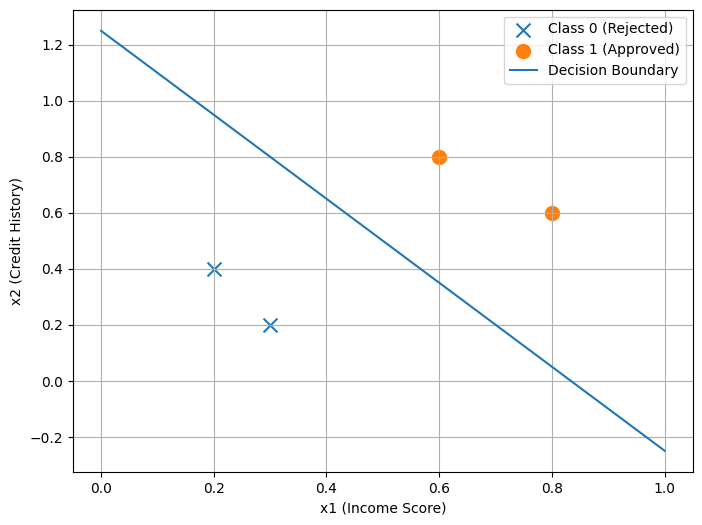

Decision boundary: 1.2000*x1 + 0.8000*x2 + -1.0000 = 0


In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_train[y_train == 0][:, 0],
    X_train[y_train == 0][:, 1],
    marker='x',
    s=100,
    label='Class 0 (Rejected)'
)

plt.scatter(
    X_train[y_train == 1][:, 0],
    X_train[y_train == 1][:, 1],
    marker='o',
    s=100,
    label='Class 1 (Approved)'
)

w1, w2 = perceptron.coef_[0]
b = perceptron.intercept_[0]

x1 = np.linspace(0, 1, 100)
x2 = -(w1 / w2) * x1 - (b / w2)

plt.plot(x1, x2, label='Decision Boundary')

plt.xlabel("x1 (Income Score)")
plt.ylabel("x2 (Credit History)")
plt.legend()
plt.grid(True)
plt.show()

print(f"Decision boundary: {w1:.4f}*x1 + {w2:.4f}*x2 + {b:.4f} = 0")    


Problem 1.2 - Applied Business Problem

Data

In [5]:
import numpy as np
from sklearn.linear_model import Perceptron
from sklearn.metrics import confusion_matrix, classification_report

X = np.array([
    [0.9, 0.7],
    [0.2, 0.3],
    [0.7, 0.5],
    [0.3, 0.8],
    [0.5, 0.4],
    [0.8, 0.9]
])

y = np.array([1, 0, 1, 0, 0, 1])


A) Training

In [6]:
model = Perceptron(eta0=1.0, max_iter=50, random_state=42)
model.fit(X, y)

print("Weights:", model.coef_)
print("Bias:", model.intercept_)
print("Iterations:", model.n_iter_)


Weights: [[1.5 0.2]]
Bias: [-1.]
Iterations: 9


B) Confusion Matrix, Report

In [7]:
y_pred = model.predict(X)

print(confusion_matrix(y, y_pred))
print(classification_report(y, y_pred))


[[3 0]
 [0 3]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         3

    accuracy                           1.00         6
   macro avg       1.00      1.00      1.00         6
weighted avg       1.00      1.00      1.00         6



C) New client (Business G)

In [8]:
x_new = np.array([[0.6, 0.6]])
prediction = model.predict(x_new)

print("Decision:", "Approved" if prediction[0] == 1 else "Rejected")


Decision: Approved


Problem 1.3 - Financial Application

In [9]:
false_positive = 8
false_negative = 5

cost_fp = 5000
cost_fn = 2000

total_cost = false_positive * cost_fp + false_negative * cost_fn
print("Total misclassification cost: $", total_cost)

Total misclassification cost: $ 50000
